In [2]:
import clusim.sim as sim
from clusim.clustering import Clustering
import numpy as np
# conda activate SPACEL
def cons_coef(adata1, adata2, cluster1, cluster2, return_all=True, alpha=.9):
    obs_names = adata1.obs_names
    c1 = Clustering(elm2clu_dict = {index: [value] for index, value in zip(obs_names, adata1.obs[cluster1])})
    
    c2 = Clustering(elm2clu_dict = {index: [value] for index, value in zip(obs_names, adata2.obs[cluster2])})
    sis, relabeled_elements = sim.element_sim_elscore(c1, c2, alpha=alpha)
    
    sis_mapped = np.zeros(len(obs_names))

    for obs_index, score_position in relabeled_elements.items():
        sis_mapped[obs_names.get_loc(obs_index)] = sis[score_position]
        
    if return_all:
        return sis_mapped, np.mean(sis_mapped)
    else:
        return sis_mapped

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import confusion_matrix
from scipy.spatial.distance import *
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
import scanpy as sc
import os, os.path as osp
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn import metrics
methods = ['Seurat', 'CARD', 'cell2location', 'GraphST', 'DestVI','RCTD', 'scVI', 'SingleR', 'spatialDWLS', 'spatialID','spotlight','tacco','Tangram']
from sklearn.metrics import adjusted_rand_score
def ASW_score(X, pred_labels):
    d = squareform(pdist(X))
    return silhouette_score(X=d,labels=pred_labels,metric='precomputed')
out_rows = []   
ad_train = sc.read_h5ad('/maiziezhou_lab2/yuling/MERFISH_spinal_cord_resolved_0718.h5ad')
st_data = ad_train[ad_train.obs['Section ID'] == '0503_F4_C',]
for m in methods: 
    i = 17
    pred_label = pd.read_csv(f'/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/{m}/0503_F4_C_output/merged_pred_{i}.csv', index_col=0)
    
    X = st_data.obsm['spatial']
    y_true = pred_label['MERFISH cell type annotation'].astype(str).to_numpy()
    y_pred = pred_label['pred'].astype(str).to_numpy()
    st_data.obs['pred'] = y_pred
    #y_true = np.char.replace(y_true, '_', '/')
    #y_pred = np.char.replace(y_pred, '_', '/')
    labels = np.unique(y_true)  # ensure we average over true classes
    precision_macro = precision_score(
        y_true, y_pred, labels=labels, average="macro", zero_division=0
    )

    labels = np.unique(np.concatenate([y_true, y_pred]))
    le = LabelEncoder().fit(labels)
    yt = le.transform(y_true)
    yp = le.transform(y_pred)
    mask = (yt == yp)
    n_correct = np.count_nonzero(mask)   
    n_total = mask.size
    acc = n_correct / n_total
    X = st_data.obsm['spatial']
    asw = ASW_score(X=X, pred_labels= y_pred)
    print(f"correct: {n_correct}/{n_total} ({acc:.2%})")
    asw = (asw + 1.0) / 2.0
    asw = max(0.0, min(1.0, float(asw)))
    runtime_file = (
        f'/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/'
        f'{m}/0503_F4_C_output/runtimeSec_memoryMiB.csv'
    )

    time_ = 0.0
    memory_ = 0.0

    if os.path.exists(runtime_file):
        try:
            rt_df = pd.read_csv(runtime_file)
            time_ = float(rt_df['runtime_sec'].iloc[0])
            memory_ = float(rt_df['peak_memory_MiB'].iloc[0])
        except Exception as e:
            print(f"[Warning] Failed to read runtime file for {m}, set to 0: {e}")
            
    f1_macro    = f1_score(yt, yp, average='macro')
    f1_weighted = f1_score(yt, yp, average='weighted')
    f1_micro    = f1_score(yt, yp, average='micro')  
    sis_map, mean_val = cons_coef(st_data, st_data, 'MERFISH cell type annotation', 'pred', return_all=True, alpha=.9)
    ari = adjusted_rand_score(yp, yt)
    recall_macro = recall_score(y_true, y_pred, average="macro") 
    ami = metrics.adjusted_mutual_info_score(y_true, y_pred)
    nmi = metrics.normalized_mutual_info_score(y_true, y_pred)
    avgbio = (nmi + ari + asw) / 3.0 if np.isfinite(asw) else np.nan
    out_rows.append({
        'Method': m, 
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'f1_micro': f1_micro,
        'precision': precision_macro,
        'recall': recall_macro,
        'ARI': ari,
        'AMI': ami,
        'NMI': nmi,
        'ASW': asw,
        'AvgBIO': avgbio,
        'ECS': mean_val,
        'Time':time_,
        'Memory': memory_
    })

        # Save to CSV
    results_df = pd.DataFrame(out_rows)
    output_path = f'/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/0503_F4_C/metrics_results.csv'
    results_df.to_csv(output_path, index=False)
    print(f"\nResults saved to: {output_path}")

    # Display the results nicely
    print("\nMetrics Summary:")
    print(results_df.to_string(index=False))

/tmp/ipykernel_377332/1716616685.py:28: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  st_data.obs['pred'] = y_pred


correct: 5035/6602 (76.26%)

Results saved to: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/0503_F4_C/metrics_results.csv

Metrics Summary:
Method  accuracy  f1_macro  f1_weighted  f1_micro  precision   recall      ARI      AMI      NMI      ASW   AvgBIO      ECS   Time  Memory
Seurat  0.762648  0.459534     0.738599  0.762648   0.499873 0.470397 0.704548 0.721596 0.735326 0.240789 0.560221 0.602278 17.958   658.0
correct: 2831/6602 (42.88%)


/home/zhuy45/miniconda3/envs/SPACEL/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



Results saved to: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/0503_F4_C/metrics_results.csv

Metrics Summary:
Method  accuracy  f1_macro  f1_weighted  f1_micro  precision   recall      ARI      AMI      NMI      ASW   AvgBIO      ECS    Time  Memory
Seurat  0.762648  0.459534     0.738599  0.762648   0.499873 0.470397 0.704548 0.721596 0.735326 0.240789 0.560221 0.602278  17.958   658.0
  CARD  0.428809  0.229672     0.331452  0.428809   0.320311 0.282741 0.326629 0.451731 0.473327 0.269599 0.356518 0.272882 113.893  1053.9
correct: 2592/6602 (39.26%)


/home/zhuy45/miniconda3/envs/SPACEL/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


...

/home/zhuy45/miniconda3/envs/SPACEL/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



Results saved to: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/0503_F4_C/metrics_results.csv

Metrics Summary:
       Method  accuracy  f1_macro  f1_weighted  f1_micro  precision   recall      ARI      AMI      NMI      ASW   AvgBIO      ECS        Time      Memory
       Seurat  0.762648  0.459534     0.738599  0.762648   0.499873 0.470397 0.704548 0.721596 0.735326 0.240789 0.560221 0.602278   17.958000  658.000000
         CARD  0.428809  0.229672     0.331452  0.428809   0.320311 0.282741 0.326629 0.451731 0.473327 0.269599 0.356518 0.272882  113.893000 1053.900000
cell2location  0.392608  0.374429     0.406610  0.392608   0.444217 0.448469 0.214802 0.414002 0.449776 0.312119 0.325566 0.223063    0.000000    0.000000
      GraphST  0.241745  0.044413     0.154055  0.241745   0.052511 0.065224 0.131777 0.240428 0.254633 0.339820 0.242077 0.127785  183.152943 7577.554688
       DestVI  0.577552  0.248710     0.502853  0.577552   0.247943 0.298487 0.481147 0.591102 0.603

/home/zhuy45/miniconda3/envs/SPACEL/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



Results saved to: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/0503_F4_C/metrics_results.csv

Metrics Summary:
       Method  accuracy  f1_macro  f1_weighted  f1_micro  precision   recall      ARI      AMI      NMI      ASW   AvgBIO      ECS        Time      Memory
       Seurat  0.762648  0.459534     0.738599  0.762648   0.499873 0.470397 0.704548 0.721596 0.735326 0.240789 0.560221 0.602278   17.958000  658.000000
         CARD  0.428809  0.229672     0.331452  0.428809   0.320311 0.282741 0.326629 0.451731 0.473327 0.269599 0.356518 0.272882  113.893000 1053.900000
cell2location  0.392608  0.374429     0.406610  0.392608   0.444217 0.448469 0.214802 0.414002 0.449776 0.312119 0.325566 0.223063    0.000000    0.000000
      GraphST  0.241745  0.044413     0.154055  0.241745   0.052511 0.065224 0.131777 0.240428 0.254633 0.339820 0.242077 0.127785  183.152943 7577.554688
       DestVI  0.577552  0.248710     0.502853  0.577552   0.247943 0.298487 0.481147 0.591102 0.603

/home/zhuy45/miniconda3/envs/SPACEL/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# please change to visualize different metrics: 
for name, d in dfs.items():
    if {'series','ECS'}.issubset(d.columns) and len(d):

"\nplt.figure(figsize=(10, 4))\n\nfor name, d in dfs.items():\n    if {'series','accuracy'}.issubset(d.columns) and len(d):\n        plt.plot(\n            d['series'], d['ARI'],\n            label=name,\n            color=colors.get(name, None),\n            linestyle=linestyles.get(name, '-'),\n            marker=markers.get(name, 'o'),\n            linewidth=1.8,\n            markersize=4\n        )\n\nplt.xlabel('series')\nplt.ylabel('score')\nplt.title('ARI by series, testing 0503_M4_S')\nplt.ylim(0, 0.8)\nplt.grid(True, alpha=0.3)\nplt.legend(title='Method', loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True, ncol=1)\nplt.tight_layout(rect=[0, 0, 0.82, 1])\nplt.show()\n"

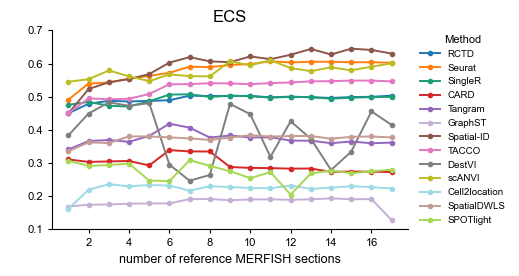

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "Arial",     
    "font.size": 8,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "black",
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    # legend
    "legend.frameon": False,
    "pdf.fonttype": 42,   # editable text in Illustrator
    "ps.fonttype": 42,
})

paths = {
    'RCTD': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/RCTD/0503_F4_C_metric/metrics_results.csv',
    'Seurat': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Seurat/0503_F4_C_metric/metrics_results.csv',
    'SingleR': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/SingleR/0503_F4_C_metric/metrics_results.csv',
    'CARD': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/CARD/0503_F4_C_metric/metrics_results.csv',
    'Tangram': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Tangram/0503_F4_C_metric/metrics_results.csv',
    'GraphST': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/GraphST/0503_F4_C_metric/metrics_results.csv',
    'Spatial-ID': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spatialID/0503_F4_C_metric/metrics_results.csv',
    'TACCO': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/tacco/0503_F4_C_metric/metrics_results.csv',
    'DestVI': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/DestVI/0503_F4_C_metric/metrics_results.csv',
    'scANVI': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/scVI/0503_F4_C_metric/metrics_results.csv',
    'Cell2location': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/cell2location/0503_F4_C_metric/metrics_results.csv',
    'SpatialDWLS': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spatialDWLS/0503_F4_C_metric/metrics_results.csv',
    'SPOTlight': '/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/spotlight/0503_F4_C_metric/metrics_results.csv',
}

dfs = {name: pd.read_csv(p) for name, p in paths.items()}

# 
for name, d in dfs.items():
    d['series'] = pd.to_numeric(d['series'], errors='coerce')
    d.sort_values('series', inplace=True)
 

colors = {
    'RCTD': '#1f77b4',        # 
    'Seurat': '#ff7f0e',      # 
    'SingleR': '#1b9e77',     # 
    'CARD': '#d62728',        # 
    'Tangram': '#9467bd',     # 
    'GraphST':      '#c5b0d5',  # 
     'Spatial-ID': '#8c564b',
     'TACCO': '#e377c2',   # 
    'DestVI': '#7f7f7f',       # 
   'scANVI': '#bcbd22',      # 
    'Cell2location':'#9edae5',  # 
    'SpatialDWLS':  '#c49c94',  # 
    'SPOTlight': '#A6D854'   # 
}


plt.figure(figsize=(7, 2.8))  

for name, d in dfs.items():
    if {'series','ECS'}.issubset(d.columns) and len(d):
        plt.plot(
            d['series'],
            d['ECS'], # change to f1_macro
            label=name,
            color=colors.get(name),
            linestyle='-',      
            marker='o',         
            linewidth=1.4,      
            markersize=3        
        )

# Axis
plt.xlabel('number of reference MERFISH sections', fontsize=9)
plt.ylabel(' ', fontsize=9)
plt.title('ECS', fontsize= 12, pad=6)

plt.ylim(0.1, 0.7)
plt.grid(False)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=8)

plt.legend(
    title='Method',
    title_fontsize=8,
    fontsize=7,
    loc='center left',
    bbox_to_anchor=(1.01, 0.5),
    handlelength=2.0
)

plt.tight_layout(rect=[0.05, 0, 0.8, 1])

plt.savefig(
    "/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/F1_based/ECS_by_series_0108.pdf",
    bbox_inches="tight"
)

'''
plt.figure(figsize=(10, 4))

for name, d in dfs.items():
    if {'series','accuracy'}.issubset(d.columns) and len(d):
        plt.plot(
            d['series'], d['ARI'],
            label=name,
            color=colors.get(name, None),
            linestyle=linestyles.get(name, '-'),
            marker=markers.get(name, 'o'),
            linewidth=1.8,
            markersize=4
        )

plt.xlabel('series')
plt.ylabel('score')
plt.title('ARI by series, testing 0503_M4_S')
plt.ylim(0, 0.8)
plt.grid(True, alpha=0.3)
plt.legend(title='Method', loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True, ncol=1)
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()
'''